In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [2]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2023-07-01",
    end="2024-06-30",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed


--- Processamento Concluído ---
Período : 2023-07-03 → 2024-06-28
Matriz  : 248 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-03,2.567155,3.018942,3.561366,2.607178,3.050475,2.567386,3.136320,3.398166,3.394385,1.597498,...,3.712428,3.362164,2.433736,3.369740,2.809334,1.947093,3.920695,2.624138,2.879222,3.548683
2023-07-04,2.549479,3.012950,3.545999,2.594370,3.044104,2.561296,3.140121,3.396311,3.394715,1.619518,...,3.723895,3.359227,2.446254,3.360212,2.799235,1.956702,3.915700,2.610745,2.877124,3.535328
2023-07-05,2.554092,3.029243,3.561116,2.593691,3.037492,2.563108,3.136320,3.390413,3.414621,1.663890,...,3.717616,3.351712,2.439319,3.377883,2.806156,1.964865,3.906859,2.634615,2.879455,3.543629
2023-07-06,2.528791,3.016151,3.535792,2.555638,3.022707,2.538672,3.128354,3.350071,3.387769,1.626751,...,3.709937,3.349285,2.418932,3.348924,2.784707,1.963509,3.899638,2.616905,2.866567,3.527229
2023-07-07,2.530139,3.033177,3.549294,2.568252,3.041905,2.545452,3.130272,3.393211,3.455766,1.660412,...,3.718965,3.353058,2.426714,3.367121,2.829748,1.984986,3.909001,2.638993,2.859704,3.530206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-24,2.309659,2.909484,3.438318,2.289322,3.174919,2.362292,3.289345,3.436745,3.248938,2.225488,...,3.850963,3.362031,2.602683,3.371305,2.991298,2.039921,3.940666,2.843708,2.981031,3.646925
2024-06-25,2.314946,2.908545,3.433735,2.271079,3.177899,2.354221,3.283380,3.432172,3.242357,2.209520,...,3.852373,3.362622,2.604580,3.373620,2.974852,2.020222,3.936552,2.814287,2.984122,3.663907
2024-06-26,2.321078,2.895300,3.428553,2.261341,3.171182,2.356649,3.268917,3.423272,3.255858,2.167398,...,3.874461,3.365865,2.604580,3.373290,2.966061,2.052841,3.948843,2.831755,3.002259,3.673007


In [ ]:
# Criando a matriz de correlação

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.75,0.35,0.96,-0.37,0.84,-0.55,0.22,0.16,-0.45,-0.64,0.56,0.91,-0.25,-0.45,0.50,-0.37,-0.01,0.34,0.57,0.69,0.58,0.55,0.81,-0.23,-0.30,-0.61,0.76,-0.42,0.89,0.77,-0.62,-0.11,-0.35,0.67,0.73,0.58,0.93,0.30,-0.48,-0.37,0.03,-0.32,0.38,-0.18,-0.03,0.22,-0.43,-0.15,-0.22
ALOS3,0.75,1.00,0.64,0.83,0.02,0.83,-0.22,0.51,-0.18,-0.14,-0.60,0.75,0.75,-0.04,-0.19,0.50,-0.18,0.13,0.47,0.80,0.85,0.17,0.39,0.47,0.11,0.08,-0.48,0.57,-0.07,0.56,0.91,-0.30,-0.12,-0.13,0.66,0.66,0.28,0.68,0.63,-0.14,-0.12,0.34,0.08,0.71,0.21,0.24,0.51,-0.02,0.29,-0.32
AXIA3,0.35,0.64,1.00,0.43,0.65,0.47,0.40,0.89,-0.29,0.45,-0.21,0.60,0.34,0.52,0.39,0.62,0.33,-0.04,0.55,0.82,0.72,-0.26,-0.22,-0.06,0.69,0.69,-0.08,0.49,0.41,0.22,0.69,0.33,-0.05,0.31,0.21,0.33,0.01,0.20,0.72,0.53,0.38,0.69,0.67,0.72,0.79,0.81,0.48,0.62,0.76,-0.10
B3SA3,0.96,0.83,0.43,1.00,-0.29,0.87,-0.47,0.32,0.10,-0.39,-0.65,0.65,0.92,-0.18,-0.38,0.57,-0.31,0.02,0.44,0.66,0.77,0.52,0.54,0.77,-0.15,-0.22,-0.58,0.76,-0.33,0.86,0.83,-0.57,-0.08,-0.30,0.68,0.76,0.56,0.92,0.35,-0.41,-0.32,0.13,-0.24,0.46,-0.09,0.05,0.28,-0.36,-0.07,-0.23
BBAS3,-0.37,0.02,0.65,-0.29,1.00,-0.12,0.88,0.76,-0.50,0.84,0.36,0.20,-0.39,0.84,0.81,0.27,0.71,0.04,0.38,0.35,0.12,-0.70,-0.65,-0.73,0.92,0.96,0.31,-0.02,0.82,-0.48,0.10,0.88,-0.04,0.61,-0.36,-0.33,-0.32,-0.54,0.53,0.96,0.58,0.77,0.94,0.44,0.94,0.85,0.31,0.95,0.85,0.11
BBDC4,0.84,0.83,0.47,0.87,-0.12,1.00,-0.35,0.39,0.00,-0.23,-0.60,0.73,0.77,-0.06,-0.31,0.44,-0.29,0.10,0.47,0.67,0.76,0.35,0.44,0.53,-0.05,-0.07,-0.50,0.70,-0.17,0.60,0.86,-0.38,-0.03,-0.16,0.71,0.59,0.38,0.80,0.57,-0.23,-0.16,0.31,-0.05,0.56,0.07,0.12,0.50,-0.17,0.12,-0.26
BBSE3,-0.55,-0.22,0.40,-0.47,0.88,-0.35,1.00,0.59,-0.46,0.75,0.51,0.04,-0.52,0.74,0.79,0.14,0.70,0.03,0.25,0.12,-0.06,-0.68,-0.58,-0.79,0.80,0.84,0.51,-0.23,0.77,-0.60,-0.13,0.91,0.09,0.54,-0.44,-0.42,-0.36,-0.68,0.27,0.92,0.61,0.64,0.84,0.21,0.78,0.67,0.21,0.87,0.71,0.17
BPAC11,0.22,0.51,0.89,0.32,0.76,0.39,0.59,1.00,-0.36,0.57,-0.03,0.58,0.21,0.68,0.58,0.68,0.53,0.01,0.64,0.73,0.61,-0.33,-0.25,-0.23,0.80,0.79,0.04,0.42,0.57,0.06,0.60,0.50,0.04,0.39,0.11,0.19,0.05,0.04,0.70,0.68,0.44,0.80,0.76,0.69,0.85,0.82,0.48,0.71,0.78,0.00
BRAV3,0.16,-0.18,-0.29,0.10,-0.50,0.00,-0.46,-0.36,1.00,-0.27,0.01,-0.25,0.18,-0.39,-0.33,0.03,-0.29,-0.38,-0.22,-0.29,-0.14,0.59,0.27,0.36,-0.46,-0.48,0.24,0.25,-0.49,0.35,-0.13,-0.46,0.55,-0.15,0.06,0.31,0.19,0.35,-0.42,-0.43,0.00,-0.42,-0.43,-0.55,-0.38,-0.29,-0.36,-0.39,-0.47,0.14
CEAB3,-0.45,-0.14,0.45,-0.39,0.84,-0.23,0.75,0.57,-0.27,1.00,0.56,0.02,-0.57,0.82,0.91,0.31,0.85,0.20,0.50,0.15,-0.15,-0.43,-0.44,-0.68,0.88,0.88,0.52,0.07,0.89,-0.49,-0.12,0.76,0.02,0.83,-0.31,-0.51,-0.14,-0.56,0.44,0.88,0.53,0.70,0.83,0.32,0.77,0.75,0.19,0.82,0.65,0.46


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.4249,Não,0.0000,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.2022,Não,0.0000,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.4533,Não,0.0000,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.6368,Não,0.0000,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.7981,Não,0.0000,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.3902,Não,0.0000,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.4209,Não,0.0000,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.4957,Não,0.0000,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.3405,Não,0.0000,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.6087,Não,0.0000,Sim,I(1) - Integrada de ordem 1


In [5]:
cesta_definitiva = df_consolidado.drop(columns=['PRIO3'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.4249,0.0100,0.0000,0.10
1,ALOS3,0.2022,0.0245,0.0000,0.10
2,AXIA3,0.4533,0.0285,0.0000,0.10
3,B3SA3,0.6368,0.0100,0.0000,0.10
4,BBAS3,0.7981,0.0100,0.0000,0.10
5,BBDC4,0.3902,0.0140,0.0000,0.10
6,BBSE3,0.4209,0.0100,0.0000,0.10
7,BPAC11,0.4957,0.0100,0.0000,0.10
8,BRAV3,0.3405,0.0235,0.0000,0.10
9,CEAB3,0.6087,0.0100,0.0000,0.10


In [6]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['CPFE3', 'CYRE3', 'EGIE3', 'ENEV3', 'ENGI11', 'LREN3', 'SANB11', 'TOTS3', 'VALE3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 47
Ativos na cesta do Johansen: 40


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,ABEV3,B3SA3,37.91,15.49,Sim,36.52,14.26,Sim,-0.6466
1,TIMS3,VBBR3,26.33,15.49,Sim,24.00,14.26,Sim,-0.7264
2,CSAN3,KLBN11,24.95,15.49,Sim,23.80,14.26,Sim,3.3982
3,ABEV3,MGLU3,24.80,15.49,Sim,22.35,14.26,Sim,-0.2353
4,GGBR4,HAPV3,24.25,15.49,Sim,18.04,14.26,Sim,-0.9439
5,CMIG4,RAIL3,23.12,15.49,Sim,22.26,14.26,Sim,1.7570
6,EQTL3,MULT3,22.67,15.49,Sim,20.70,14.26,Sim,-0.7330
7,BBSE3,PETR4,22.45,15.49,Sim,20.37,14.26,Sim,-0.3834
8,BPAC11,USIM5,22.15,15.49,Sim,20.65,14.26,Sim,-0.4079
9,CSAN3,RAIL3,21.93,15.49,Sim,21.39,14.26,Sim,-2.7729


In [7]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 47 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,HAPV3 x WEGE3,-0.045589,15.20
1,EQTL3 x RAIL3,-0.033843,20.48
2,BBDC4 x RADL3,-0.032533,21.31
3,ALOS3 x EQTL3,-0.030198,22.95
4,ALOS3 x MULT3,-0.029096,23.82
5,GGBR4 x HAPV3,-0.028570,24.26
6,ALOS3 x BBDC4,-0.024757,28.00
7,MGLU3 x RAIL3,-0.023219,29.85
8,EQTL3 x MULT3,-0.022211,31.21
9,CSAN3 x RAIL3,-0.020235,34.26


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 47 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,HAPV3 x WEGE3,16.80,0.0912,0.1624
1,GGBR4 x HAPV3,24.25,-0.9439,0.2282
2,CSAN3 x RAIL3,21.93,-2.7729,0.3104
3,BBSE3 x PETR4,22.45,-0.3834,0.3297
4,MGLU3 x RAIL3,17.98,-6.6127,0.3313
5,EQTL3 x RAIL3,16.46,-1.0784,0.3459
6,BBDC4 x RADL3,17.19,-1.9531,0.3576
7,UGPA3 x WEGE3,18.78,7.8184,0.3697
8,PSSA3 x UGPA3,16.17,-0.1093,0.3879
9,HYPE3 x KLBN11,16.56,2.7446,0.3915


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,HAPV3 x WEGE3,HAPV3,WEGE3,16.80,14.37,0.0912,15.20,0.1624
1,GGBR4 x HAPV3,GGBR4,HAPV3,24.25,18.04,-0.9439,24.26,0.2282
2,CSAN3 x RAIL3,CSAN3,RAIL3,21.93,21.39,-2.7729,34.26,0.3104
3,BBSE3 x PETR4,BBSE3,PETR4,22.45,20.37,-0.3834,64.24,0.3297
4,MGLU3 x RAIL3,MGLU3,RAIL3,17.98,16.25,-6.6127,29.85,0.3313
5,EQTL3 x RAIL3,EQTL3,RAIL3,16.46,12.85,-1.0784,20.48,0.3459
6,BBDC4 x RADL3,BBDC4,RADL3,17.19,14.17,-1.9531,21.31,0.3576
7,UGPA3 x WEGE3,UGPA3,WEGE3,18.78,16.43,7.8184,47.77,0.3697
8,PSSA3 x UGPA3,PSSA3,UGPA3,16.17,13.48,-0.1093,58.06,0.3879
9,HYPE3 x KLBN11,HYPE3,KLBN11,16.56,13.99,2.7446,42.85,0.3915


In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DOS PARES PARA BACKTEST
# ==============================================================================

# 1. Garante que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplica as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 6 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,HAPV3 x WEGE3,HAPV3,WEGE3,16.80,14.37,0.0912,15.20,0.1624
1,GGBR4 x HAPV3,GGBR4,HAPV3,24.25,18.04,-0.9439,24.26,0.2282
2,MGLU3 x RAIL3,MGLU3,RAIL3,17.98,16.25,-6.6127,29.85,0.3313
3,EQTL3 x RAIL3,EQTL3,RAIL3,16.46,12.85,-1.0784,20.48,0.3459
4,BBDC4 x RADL3,BBDC4,RADL3,17.19,14.17,-1.9531,21.31,0.3576
5,ALOS3 x EQTL3,ALOS3,EQTL3,19.34,15.73,-1.0535,22.95,0.4903


In [11]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2023-07-01':'2024-06-01'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,HAPV3 x WEGE3_Spread,HAPV3 x WEGE3_Z-Score,GGBR4 x HAPV3_Spread,GGBR4 x HAPV3_Z-Score,MGLU3 x RAIL3_Spread,MGLU3 x RAIL3_Z-Score,EQTL3 x RAIL3_Spread,EQTL3 x RAIL3_Z-Score,BBDC4 x RADL3_Spread,BBDC4 x RADL3_Z-Score,ALOS3 x EQTL3_Spread,ALOS3 x EQTL3_Z-Score
Date,,,,,,,,,,,,
2023-07-03,3.870550,0.634068,6.907184,0.953067,23.655648,1.221241,6.706441,-0.049205,8.996573,1.330327,6.601306,0.350425
2023-07-04,3.848884,0.392645,6.883656,0.788902,23.667140,1.247109,6.715971,0.070297,8.967951,1.127286,6.599849,0.335247
2023-07-05,3.861920,0.537906,6.892810,0.852774,23.716619,1.358479,6.729756,0.243130,8.982085,1.227555,6.624190,0.588703
2023-07-06,3.847305,0.375054,6.867874,0.678779,23.503008,0.877674,6.702665,-0.096543,8.922423,0.804316,6.605631,0.395456
2023-07-07,3.860858,0.526077,6.902970,0.923666,23.600383,1.096849,6.725834,0.193961,8.959602,1.068057,6.631965,0.669663
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-24,3.830548,0.188332,6.782397,0.082358,22.080134,-2.324983,6.536249,-2.183151,8.629197,-1.275808,6.430158,-1.431687
2024-05-27,3.832869,0.214193,6.773329,0.019085,22.073083,-2.340852,6.544962,-2.073901,8.615588,-1.372351,6.442710,-1.300989
2024-05-28,3.804649,-0.100251,6.744259,-0.183751,21.949864,-2.618198,6.519330,-2.395289,8.608021,-1.426031,6.413009,-1.610257


In [12]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2024-07-01",
                          end="2024-12-31", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading


Periodo de trading: 2024-07-01 → 2024-12-30
Dias úteis        : 127
Pares processados : 6


,HAPV3 x WEGE3_Beta_Kalman,HAPV3 x WEGE3_Spread,HAPV3 x WEGE3_Z-Score,GGBR4 x HAPV3_Beta_Kalman,GGBR4 x HAPV3_Spread,GGBR4 x HAPV3_Z-Score,MGLU3 x RAIL3_Beta_Kalman,MGLU3 x RAIL3_Spread,MGLU3 x RAIL3_Z-Score,EQTL3 x RAIL3_Beta_Kalman,EQTL3 x RAIL3_Spread,EQTL3 x RAIL3_Z-Score,BBDC4 x RADL3_Beta_Kalman,BBDC4 x RADL3_Spread,BBDC4 x RADL3_Z-Score,ALOS3 x EQTL3_Beta_Kalman,ALOS3 x EQTL3_Spread,ALOS3 x EQTL3_Z-Score
Date,,,,,,,,,,,,,,,,,,
2024-07-01,0.847470,3.697312,-1.296286,0.325977,6.642952,-0.890629,-1.387920,22.086920,-2.309707,0.485585,6.611495,-1.239675,-0.016075,8.571355,-1.686140,0.346969,6.483500,-0.876255
2024-07-02,0.863142,3.686486,-1.416913,0.351751,6.641552,-0.900394,-1.226666,22.118216,-2.239265,0.531252,6.599511,-1.389938,0.037441,8.548157,-1.850702,0.381191,6.451107,-1.213553
2024-07-03,0.871546,3.730998,-0.920926,0.359088,6.676126,-0.659151,-1.165717,22.296760,-1.837393,0.547498,6.639598,-0.887313,0.056250,8.575952,-1.653529,0.394264,6.490733,-0.800942
2024-07-04,0.877110,3.751833,-0.688770,0.362141,6.689873,-0.563231,-1.131345,22.405590,-1.592434,0.556312,6.664627,-0.573486,0.066051,8.544982,-1.873222,0.402148,6.534723,-0.342887
2024-07-05,0.879994,3.746131,-0.752298,0.363517,6.671861,-0.688912,-1.108348,22.489851,-1.402776,0.561552,6.674636,-0.447994,0.072513,8.567901,-1.710641,0.407569,6.553205,-0.150445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,0.820706,3.213986,-6.681877,0.391064,6.282843,-3.403313,-1.102433,20.920689,-4.934703,0.586324,6.409006,-3.778583,0.125665,8.339333,-3.332084,0.426123,6.297371,-2.814361
2024-12-23,0.819263,3.159844,-7.285162,0.391576,6.204040,-3.953167,-1.104071,20.710718,-5.407315,0.586105,6.340350,-4.639424,0.125192,8.310122,-3.539307,0.425895,6.236732,-3.445782
2024-12-26,0.817792,3.150212,-7.392490,0.392084,6.192943,-4.030594,-1.105931,20.559929,-5.746716,0.585900,6.322681,-4.860966,0.124751,8.310965,-3.533329,0.425643,6.222206,-3.597037


In [13]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 6 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,MGLU3 x RAIL3,0.3313,29.85,33
1,HAPV3 x WEGE3,0.1624,15.20,17
2,EQTL3 x RAIL3,0.3459,20.48,10
3,GGBR4 x HAPV3,0.2282,24.26,4
4,BBDC4 x RADL3,0.3576,21.31,4
5,ALOS3 x EQTL3,0.4903,22.95,3


In [14]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
HAPV3 x WEGE3                     -1.84    -8.00     0.84  ✗ DIVERGIU
GGBR4 x HAPV3                     -0.86    -4.25     0.67        ✓ OK
MGLU3 x RAIL3                     -2.53    -5.86     0.07  ✗ DIVERGIU
EQTL3 x RAIL3                     -1.00    -5.14     2.04        ✓ OK
BBDC4 x RADL3                     -0.53    -3.92     1.99        ✓ OK
ALOS3 x EQTL3                     -0.34    -3.83     1.48        ✓ OK


In [15]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 4
Pares excluídos : 2

Excluídos por divergência do spread:
  HAPV3 x WEGE3                   média z-score = -1.84
  MGLU3 x RAIL3                   média z-score = -2.53


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,GGBR4 x HAPV3,GGBR4,HAPV3,24.25,18.04,-0.9439,24.26,0.2282
1,EQTL3 x RAIL3,EQTL3,RAIL3,16.46,12.85,-1.0784,20.48,0.3459
2,BBDC4 x RADL3,BBDC4,RADL3,17.19,14.17,-1.9531,21.31,0.3576
3,ALOS3 x EQTL3,ALOS3,EQTL3,19.34,15.73,-1.0535,22.95,0.4903


In [16]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")


Pares após limite: 4


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 4
Retorno acumulado líquido : -5.46%
Retorno médio anualizado  : -11.11%
Volatilidade anualizada   : 4.99%
Sharpe anualizado         : -2.2255
Maximum Drawdown          : -5.58%

Retorno acumulado por par:
EQTL3 x RAIL3   -9.79
BBDC4 x RADL3   -8.66
ALOS3 x EQTL3   -2.48
GGBR4 x HAPV3   -1.31

Pares lucrativos: 0
Pares com perda : 4


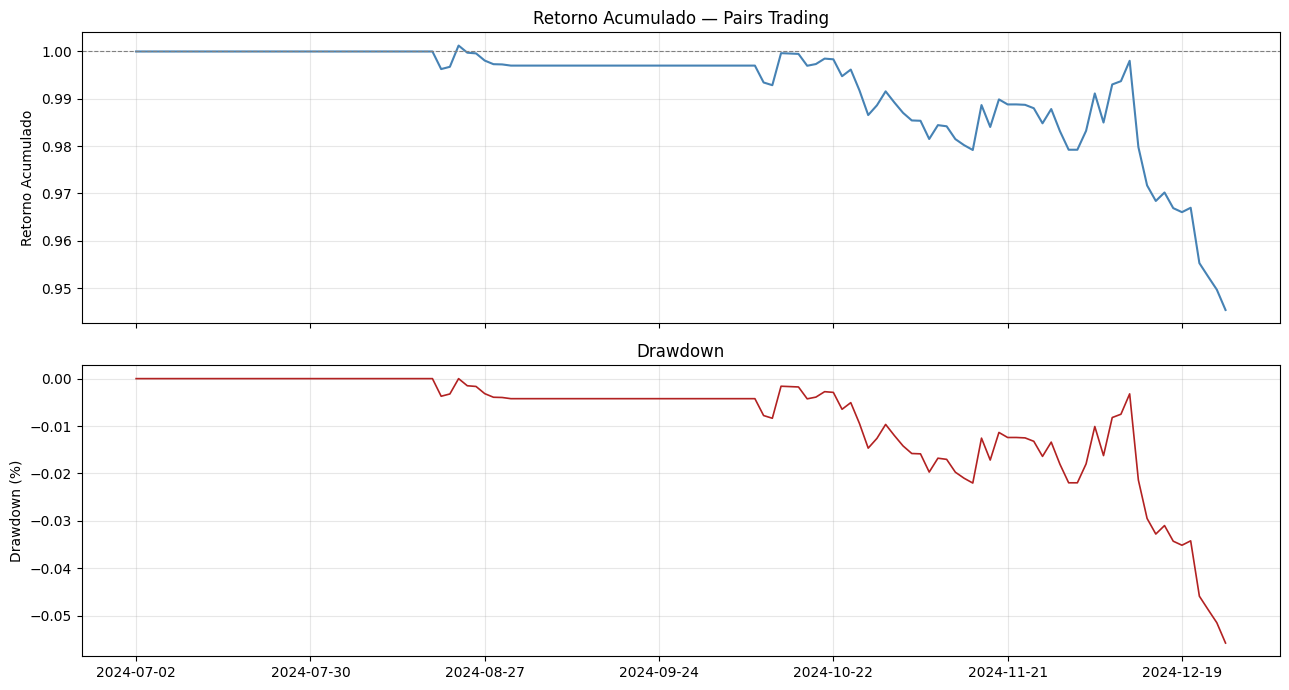

In [17]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_5_jul2023_dez2024.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_5_jul2023_dez2024.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 4 pares
  2_ZScores_Trading    : 6 séries
  3_Retornos_Por_Par   : 4 pares × 126 dias
  4_Retorno_Carteira   : 126 dias
  5_Estatisticas       : 22 trades no período


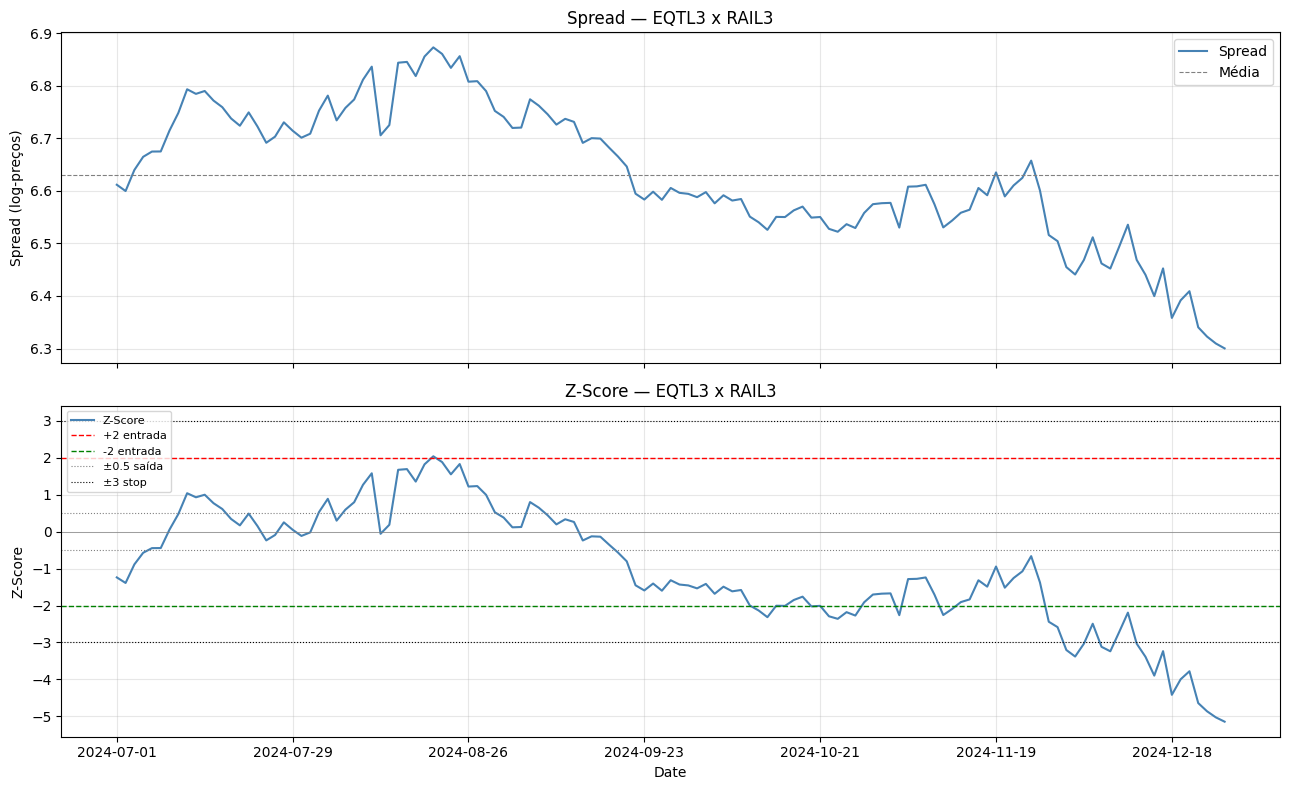

In [21]:
par    = 'EQTL3 x RAIL3'

z      = df_historico_trading[f'{par}_Z-Score']
spread = df_historico_trading[f'{par}_Spread']

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Painel 1 — Spread
spread.plot(ax=axes[0], color='steelblue', linewidth=1.5, label='Spread')
axes[0].axhline(spread.mean(), color='gray', linestyle='--',
                linewidth=0.8, label='Média')
axes[0].set_title(f'Spread — {par}')
axes[0].set_ylabel('Spread (log-preços)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Painel 2 — Z-Score
z.plot(ax=axes[1], color='steelblue', linewidth=1.5, label='Z-Score')

# Linhas de referência
axes[1].axhline( 2.0, color='red',   linestyle='--', linewidth=1,   label='+2 entrada')
axes[1].axhline(-2.0, color='green', linestyle='--', linewidth=1,   label='-2 entrada')
axes[1].axhline( 0.5, color='gray',  linestyle=':',  linewidth=0.8, label='±0.5 saída')
axes[1].axhline(-0.5, color='gray',  linestyle=':',  linewidth=0.8)
axes[1].axhline( 3.0, color='black', linestyle=':',  linewidth=0.8, label='±3 stop')
axes[1].axhline(-3.0, color='black', linestyle=':',  linewidth=0.8)
axes[1].axhline( 0.0, color='gray',  linestyle='-',  linewidth=0.5)

axes[1].set_title(f'Z-Score — {par}')
axes[1].set_ylabel('Z-Score')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'spread_{par.replace(" x ", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()